# Computer Vision on TOURCAST Screenshots

A computer vision model trained on the screenshots from the TOURCAST website. Using this dataset: https://www.kaggle.com/datasets/samanthastaheli/tournamenttourcastholeimages

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision.models import resnet50, ResNet50_Weights

import os
import kagglehub
from PIL import Image
import numpy as np
import pandas as pd

## Load Data

In [ ]:
# Download latest version of the dataset
path = kagglehub.dataset_download("samanthastaheli/tournamenttourcastholeimages")
print("Path to dataset files:", path)

100%|██████████| 26.5G/26.5G [04:46<00:00, 99.2MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/samanthastaheli/tournamenttourcastholeimages/versions/1


In [ ]:
class PGAImagesDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        # Gather all image files
        self.image_files = [
            f for f in os.listdir(img_dir)
            if f.endswith(('.png', '.jpg', '.jpeg'))
        ]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # Load image
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Example: Extract label from filename (or return filename/index for unsupervised learning)
        # If filenames contain info like tournament ID or shot type, parse it here:
        # label = parse_label_from_filename(img_name)

        return image, img_name

In [ ]:
# Directory containing all images
pga_images_dir = os.path.join(path, "PGAImages")

# Transforms
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Initialize Dataset
dataset = PGAImagesDataset(img_dir=pga_images_dir, transform=data_transforms)
print(f"Total images found: {len(dataset)}")

# Train/Val Split (80% / 20%)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

# shorten dataset for testing
from torch.utils.data import Subset
small_dataset = Subset(dataset, range(100))

# Dataloaders
# train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=4)
# val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=4)
# loader = DataLoader(dataset, batch_size=64, shuffle=False)
loader = DataLoader(small_dataset, batch_size=64, shuffle=False)
print(f"Total batches in dataset: {len(loader)}")

Total images found: 29422
Total batches in dataset: 2


## Model

### Feature Extraction

In [ ]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Remove classification head to get raw feature vector (2048 dimensions)
        self.features = nn.Sequential(*list(resnet.children())[:-1])

    def forward(self, x):
        x = self.features(x)
        return torch.flatten(x, 1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
extractor = FeatureExtractor().to(device)
extractor.eval()

# 2. Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 110MB/s]


In [ ]:
embeddings = []
filenames = []

with torch.no_grad():
    for imgs, fnames in loader:
        imgs = imgs.to(device)
        feats = extractor(imgs)
        embeddings.append(feats.cpu().numpy())
        filenames.extend(fnames)

embeddings = np.vstack(embeddings)
print(f"Extracted feature matrix shape: {embeddings.shape}")

Extracted feature matrix shape: (100, 2048)


### Cluster and Find Player Patterns

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Reduce dimensionality for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(embeddings)

# 2. Group similar shot visual patterns using K-Means
num_clusters = 4  # e.g., Conservative Tee, Aggressive Pin, Fairway Center, Hazard Miss
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

# 3. Build a structured DataFrame linking images to clusters
df_patterns = pd.DataFrame({
    'filename': filenames,
    'cluster': cluster_labels,
    'pca_x': reduced_features[:, 0],
    'pca_y': reduced_features[:, 1]
})

# Example: Extract player ID / Shot ID from filename pattern (adjust regex for your dataset)
# e.g., "tournament_R2025011_player12345_shot2.png" -> player_id: "12345"
df_patterns['player_id'] = df_patterns['filename'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown')

# 4. Analyze Player Tendencies (Cluster Frequency per Player)
player_tendencies = pd.crosstab(df_patterns['player_id'], df_patterns['cluster'], normalize='index')
print("\nPlayer Cluster Distribution (% of shots in each pattern):")
print(player_tendencies.head())


Player Cluster Distribution (% of shots in each pattern):
cluster       0     1     2     3
player_id                        
player     0.15  0.48  0.25  0.12


In [ ]:
# First run with all data:
# Player Cluster Distribution (% of shots in each pattern):
# cluster           0         1         2         3
# player_id
# player     0.137482  0.220889  0.258004  0.383624

## Results

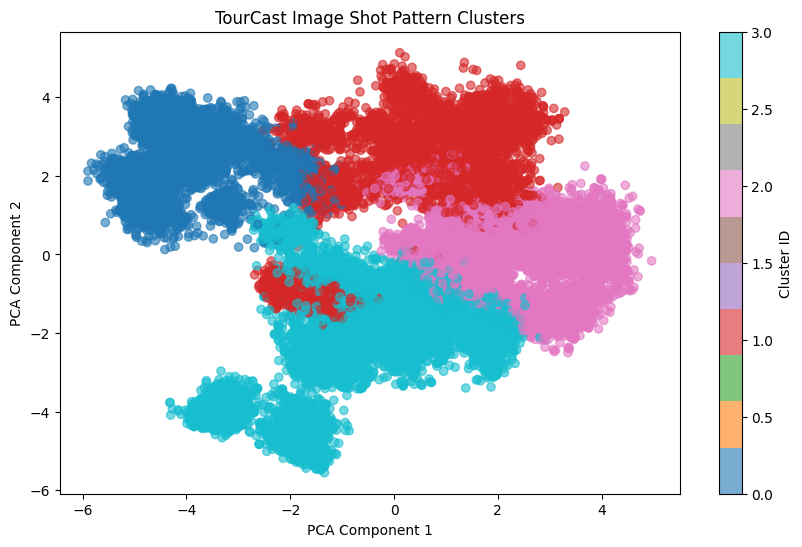

In [ ]:
# Visualize Pattern Clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_patterns['pca_x'], df_patterns['pca_y'], c=df_patterns['cluster'], cmap='tab10', alpha=0.6)
plt.title("TourCast Image Shot Pattern Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster ID')
plt.show()

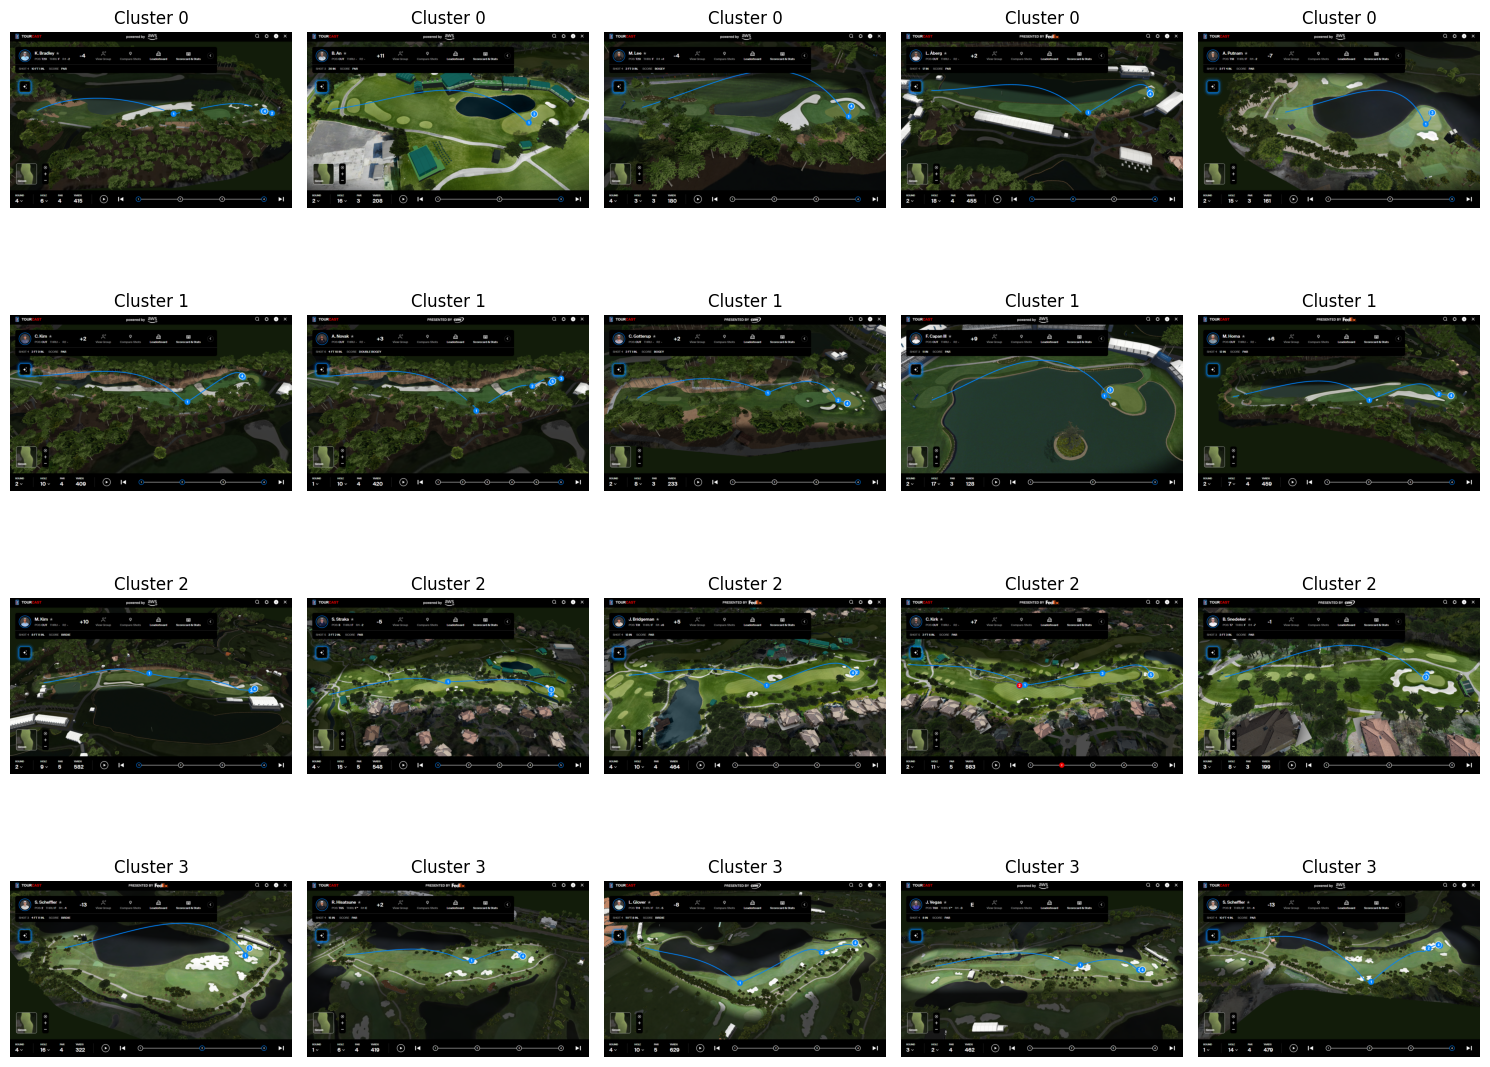

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def display_cluster_samples(df_patterns, img_dir, num_clusters=4, samples_per_cluster=5):
    fig, axes = plt.subplots(num_clusters, samples_per_cluster, figsize=(15, 3 * num_clusters))

    for cluster_id in range(num_clusters):
        # Filter images belonging to this cluster
        cluster_files = df_patterns[df_patterns['cluster'] == cluster_id]['filename'].values

        # Select up to `samples_per_cluster` images
        selected_files = cluster_files[:samples_per_cluster]

        for i in range(samples_per_cluster):
            ax = axes[cluster_id, i] if num_clusters > 1 else axes[i]

            if i < len(selected_files):
                img_path = os.path.join(img_dir, selected_files[i])
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(f"Cluster {cluster_id}")

            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run the function using your pga_images_dir and df_patterns
display_cluster_samples(df_patterns, pga_images_dir, num_clusters=4, samples_per_cluster=5)

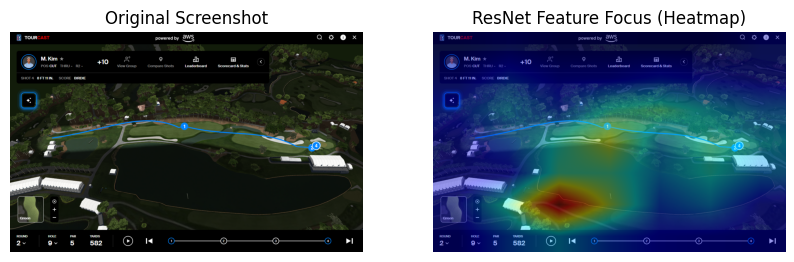

In [ ]:
import cv2
import numpy as np

# 1. Modify FeatureExtractor to return high-resolution activation maps
class FeatureMapExtractor(nn.Module):
    def __init__(self):
        super(FeatureMapExtractor, self).__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Keep everything up to the layer4 conv block (before avgpool)
        self.feature_conv = nn.Sequential(*list(resnet.children())[:-2])

    def forward(self, x):
        return self.feature_conv(x) # Output shape: (B, 2048, 7, 7)

map_extractor = FeatureMapExtractor().to(device)
map_extractor.eval()

# 2. Function to overlay feature heatmaps onto an image
def visualize_image_feature_heatmap(img_path):
    orig_img = Image.open(img_path).convert("RGB")
    input_tensor = data_transforms(orig_img).unsqueeze(0).to(device)

    with torch.no_grad():
        conv_out = map_extractor(input_tensor) # (1, 2048, 7, 7)

    # Average across the 2048 channels to get spatial activation magnitude
    heatmap = torch.mean(conv_out, dim=1).squeeze().cpu().numpy()

    # Normalize heatmap between 0 and 1
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    # Resize heatmap to match original image size
    orig_np = np.array(orig_img)
    heatmap_resized = cv2.resize(heatmap, (orig_np.shape[1], orig_np.shape[0]))

    # Apply color map
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # Blend heatmap with original image
    overlay = cv2.addWeighted(orig_np, 0.6, heatmap_color, 0.4, 0)

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(orig_img)
    axes[0].set_title("Original Screenshot")
    axes[0].axis('off')

    axes[1].imshow(overlay)
    axes[1].set_title("ResNet Feature Focus (Heatmap)")
    axes[1].axis('off')
    plt.show()

# Example usage on any single file from your dataset:
sample_file = df_patterns['filename'].iloc[0]
visualize_image_feature_heatmap(os.path.join(pga_images_dir, sample_file))